# 1. Dataset Import

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../Data/my_data.csv")
df.drop(columns=['name'],inplace=True)

In [3]:
df.isnull().mean() * 100

city          17.727273
gender         9.636364
profession    16.272727
age           10.727273
cgpa          12.545455
placed         0.000000
dtype: float64

In [4]:
df['profession'].value_counts()

profession
bachelor    517
masters     273
phd         131
Name: count, dtype: int64

In [5]:
df['profession'].unique() 

<StringArray>
['phd', 'bachelor', 'masters', nan]
Length: 4, dtype: str

In [29]:
df['placed'].value_counts()

placed
0    551
1    549
Name: count, dtype: int64

In [6]:
df['city'].value_counts()

city
wakanda       391
gotham        243
asgard        152
purgatory     119
Name: count, dtype: int64

In [7]:
df.columns

Index(['city', 'gender', 'profession', 'age', 'cgpa', 'placed'], dtype='str')

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df.iloc[:,-1], test_size=0.2, random_state=42)

# 2. Dataset Analysis

C:\Users\Jehan\AppData\Local\Temp\ipykernel_9348\3590550407.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\Jehan\AppData\Local\Temp\ipykernel_9348\3590550407.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


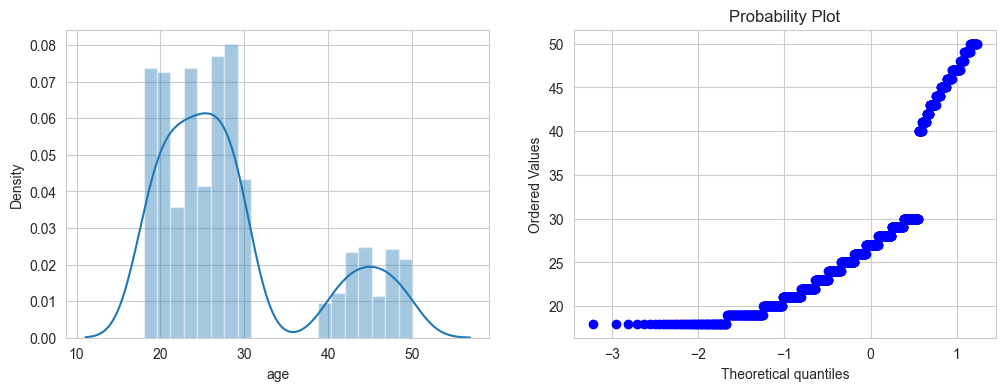

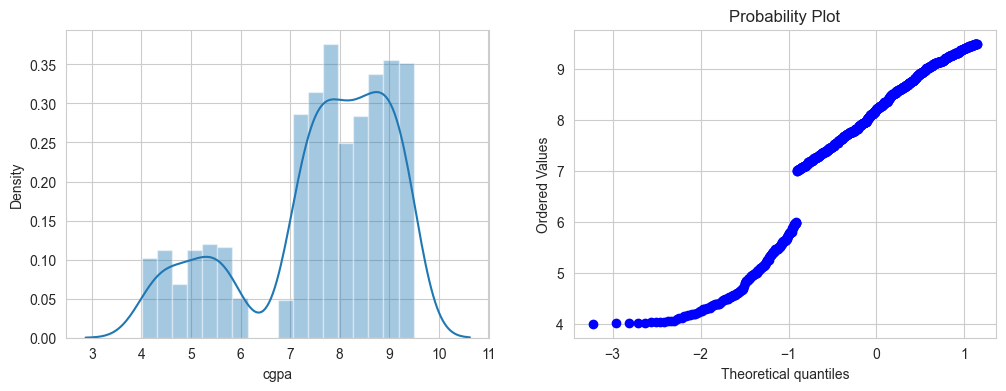

In [9]:
import scipy.stats as stats

numerical_cols = ['age', 'cgpa']
for col in numerical_cols:
    plt.figure(figsize=(12,4))
    
    plt.subplot(121)
    sns.distplot(df[col])
    
    plt.subplot(122)
    stats.probplot(df[col], dist='norm', plot=plt)

In [10]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer

In [11]:
def applyDifferentBinning(nbins, strategy):
    age_cg_pipe = Pipeline([
        ("impt",KNNImputer(n_neighbors=3, weights='distance')),
        ("age_encod", KBinsDiscretizer(encode='ordinal', n_bins=nbins, strategy=strategy)),
    ])
    trf_pipe = ColumnTransformer(transformers=[
        ("prep", age_cg_pipe, ['age','cgpa'])
    ])

    X_train_encod = trf_pipe.fit_transform(X_train)
    
    plt.figure(figsize=(16,12))
    plt.subplot(221)
    plt.hist(X_train['age'], color="green")
    plt.title("Age without Binning")
    
    plt.subplot(222)
    plt.hist(X_train_encod[:,0], color="red")
    plt.title("Age Binning")
    
    plt.subplot(223)
    plt.hist(X_train['cgpa'], color="purple")
    plt.title("CGPA without Binning")
    
    plt.subplot(224)
    plt.hist(X_train_encod[:,1], color="blue")
    plt.title("CGPA Binning")
    

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


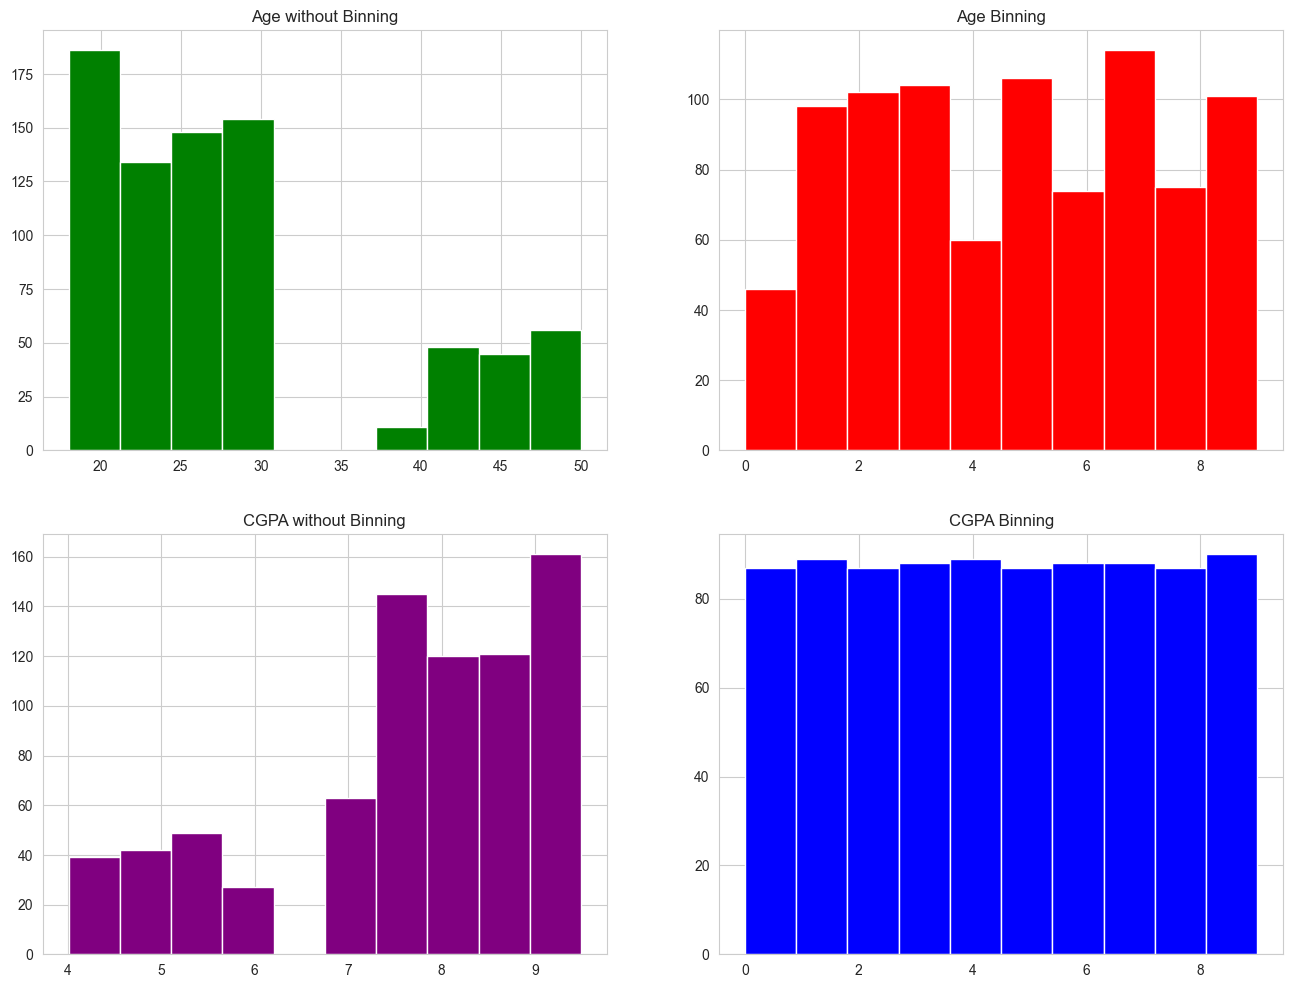

In [12]:
applyDifferentBinning(10,"quantile")

In [13]:
def findOutlier(df, col):
    highest_allowed_data = df[col].mean() + (3 * df[col].std())
    lowest_allowed_data = df[col].mean() - (3 * df[col].std())
    print(highest_allowed_data,lowest_allowed_data)
    return df[(df[col] > highest_allowed_data) | (df[col] < lowest_allowed_data)]

In [14]:
findOutlier(df,'age')

55.853466290666276 1.0060041777654938


,city,gender,profession,age,cgpa,placed


In [15]:
findOutlier(df,'cgpa')

12.097004910431682 3.1210616176348447


,city,gender,profession,age,cgpa,placed


In [16]:
def findOutlierIQR(df, col):
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)
    highest_allowed_data = df[col].quantile(0.75) + (1.5*iqr)
    lowest_allowed_data = df[col].quantile(0.25) - (1.5*iqr)
    print(highest_allowed_data, lowest_allowed_data)
    return df[(df[col] > highest_allowed_data) | (df[col] < lowest_allowed_data)]

In [17]:
findOutlierIQR(df,'age')

42.0 10.0


,city,gender,profession,age,cgpa,placed
1,asgard,NaN,bachelor,50.0,8.55,0
12,wakanda,male,bachelor,48.0,8.75,0
16,wakanda,male,masters,43.0,7.74,1
27,gotham,male,bachelor,44.0,9.30,1
32,NaN,male,masters,46.0,NaN,0
...,...,...,...,...,...,...
955,gotham,female,bachelor,43.0,5.00,0
965,wakanda,male,bachelor,43.0,8.24,0
990,wakanda,male,NaN,47.0,7.76,0
994,gotham,male,bachelor,50.0,NaN,1


In [18]:
findOutlierIQR(df,'cgpa')

11.145 4.785


,city,gender,profession,age,cgpa,placed
36,wakanda,female,masters,46.0,4.04,0
57,purgatory,female,bachelor,47.0,4.50,0
67,NaN,male,phd,23.0,4.43,1
70,gotham,male,bachelor,NaN,4.50,0
71,purgatory,male,phd,26.0,4.58,1
...,...,...,...,...,...,...
945,NaN,male,bachelor,46.0,4.42,1
947,gotham,male,masters,48.0,4.54,0
948,wakanda,male,NaN,28.0,4.49,0
977,wakanda,male,bachelor,18.0,4.26,1


# 3. Preprocessing

In [19]:
from sklearn.base import BaseEstimator, TransformerMixin

class RandomSelectImputer(BaseEstimator, TransformerMixin):
    def __init__(self, random_state=None):
        self.random_state = random_state

    def fit(self, X, y=None):
        self.rng_ = np.random.default_rng(self.random_state)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            missing = X[col].isnull()
            if missing.sum() > 0:
                observed_values = X.loc[~missing, col]
                
                if len(observed_values) > 0:
                    X.loc[missing, col] = self.rng_.choice(
                        observed_values, size=missing.sum(), replace=True
                    )
        return X

In [20]:
from sklearn.base import BaseEstimator, TransformerMixin
class IQRCap(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        self.IQR_ = Q3 - Q1
        self.lower_ = Q1 - 1.5 * self.IQR_
        self.upper_ = Q3 + 1.5 * self.IQR_
        return self
    
    def transform(self, X):
        return np.clip(X, self.lower_, self.upper_)

In [21]:
prof_pipe = Pipeline([
    ("imp",SimpleImputer(strategy='most_frequent')),
    ("oen",OrdinalEncoder(categories=[['bachelor', 'phd' , 'masters']]))
])

city_gen_pipe = Pipeline([
    ("imp",RandomSelectImputer()),
    ("ohe",OneHotEncoder(drop='first',sparse_output=False))
])

age_cg_pipe = Pipeline([
    ("impt",KNNImputer(n_neighbors=3, weights='distance')),
    ("outlier",IQRCap()),
    ("std",StandardScaler()),
    ("bins", KBinsDiscretizer(strategy='quantile', n_bins=10, encode='ordinal')),
    ("power",PowerTransformer()),
])

In [22]:
preprocessor = ColumnTransformer(transformers=[
    ("city_gender", city_gen_pipe , ['city', 'gender']),
    ("prof", prof_pipe, ['profession']),
    ("age_cg",age_cg_pipe,['age', 'cgpa'])
],remainder='passthrough')

In [23]:
X_train_trf = preprocessor.fit_transform(X_train)
X_test_trf = preprocessor.transform(X_test)

F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
F:\Data_Science\Machine_Learning\MachineTrain_Lab\.venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:396: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


In [24]:
X_train_trf

array([[ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.91534566,  1.45222897],
       [ 0.        ,  0.        ,  1.        , ...,  1.        ,
         1.2652943 ,  0.86909559],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
        -1.38779944, -1.24074932],
       ...,
       [ 0.        ,  1.        ,  0.        , ...,  0.        ,
         0.19414669,  0.56250862],
       [ 0.        ,  0.        ,  0.        , ...,  2.        ,
         0.19414669,  1.16517723],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
        -0.96592688,  1.45222897]], shape=(880, 7))

# Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

def modelEvaluation(model_cls):
    # copy_cls = clone(model_cls)
    model_cls.fit(X_train_trf,y_train)
    y_pred = model_cls.predict(X_test_trf)
    print("Accuracy: ",accuracy_score(y_test, y_pred))
    # X = pd.concat([X_train_trf,X_test_trf],axis=0)
    # y = pd.concat([y_train,y_test],axis=0)
    # 
    # print("Cross Val Accuracy: ",cross_val_score(copy_cls, X,y,cv=10,scoring='accuracy'))
    print("Precision: ",precision_score(y_test, y_pred))
    print("Recall: ",recall_score(y_test, y_pred))
    print("F1 score: ",f1_score(y_test, y_pred))
    print("Confusion Matrix: ")
    
    plt.figure(figsize=(6,4))
    labels = np.unique(y_test)
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Accuracy:  0.4909090909090909
Precision:  0.4928571428571429
Recall:  0.6272727272727273
F1 score:  0.552
Confusion Matrix: 


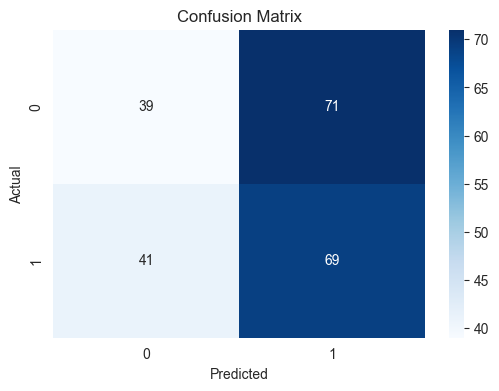

In [31]:
from sklearn.linear_model import LogisticRegression
modelEvaluation(LogisticRegression())

Accuracy:  0.5
Precision:  0.5
Recall:  0.39090909090909093
F1 score:  0.4387755102040816
Confusion Matrix: 


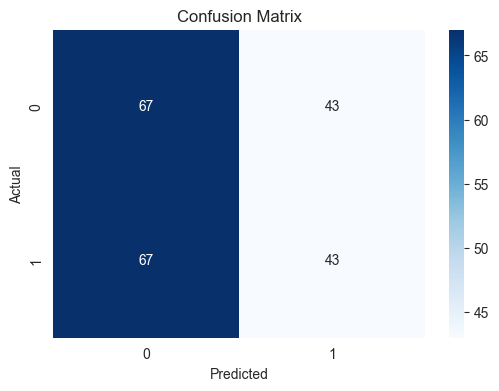

In [32]:
from sklearn.tree import DecisionTreeClassifier
modelEvaluation(DecisionTreeClassifier())

Accuracy:  0.5272727272727272
Precision:  0.5277777777777778
Recall:  0.5181818181818182
F1 score:  0.5229357798165137
Confusion Matrix: 


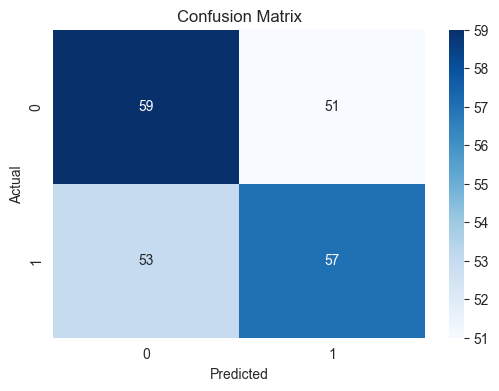

In [33]:
from sklearn.ensemble import RandomForestClassifier
modelEvaluation(RandomForestClassifier())

Accuracy:  0.5272727272727272
Precision:  0.5263157894736842
Recall:  0.5454545454545454
F1 score:  0.5357142857142857
Confusion Matrix: 


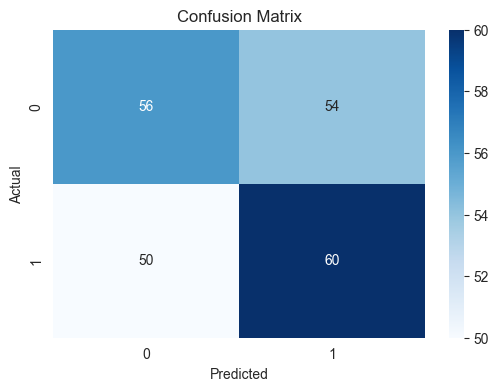

In [34]:
from xgboost import XGBClassifier
modelEvaluation(XGBClassifier())